In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch08. 다양한_DNN모델(iris종별예측)</font>

```
- 데이터셋 생성 및 전처리
    X, y(라벨 인코딩) 분리 >> train_test_split (8:2)
- 모델 구성
    입력 4, 출력 3, 레이어 : 4-64-128-60-30-3
- 모델 학습과정 설정 (loss='sparse_categorical_crossentropy')
- 모델 학습 (callbacks)
- 모델 평가 (ModelCheckpoint)
- 모델 사용
```

In [106]:
import numpy as np
import pandas as pd

from sklearn import datasets
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.metrics import Recall, Precision

import matplotlib.pyplot as plt
import seaborn as sns

# 1. default DNN

## 1. 데이터셋 생성 및 전처리

### 1.1 seaborn을 통한 데이터셋 생성

In [4]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
iris_X = iris.iloc[:,:-1].values
label = LabelEncoder()
iris_y = label.fit_transform(iris.iloc[:,-1])
iris_X.shape, iris_y.shape

((150, 4), (150,))

### 1.2 sklearn을 통한 데이터셋 생성

In [17]:
irisData = datasets.load_iris()
iris_X = irisData.data
iris_y = irisData.target
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [18]:
# 학습 데이터셋과 시험 데이터셋 분리
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y, test_size=0.2, stratify=iris_y)

In [20]:
train_X.shape, test_X.shape, test_X.shape, test_y.shape

((120, 4), (30, 4), (30, 4), (30,))

## 2. 모델 구성 및 학습 
- 입력 4, 출력 3, 레이어 : 4-64-128-60-30-3

In [37]:
model = Sequential(name='seq')
model.add(Input(shape=(4,)))
model.add(Dense(units=64, activation='relu', kernel_regularizer=l2(0.0002), kernel_initializer='he_normal'))
model.add(Dropout(0.4))

model.add(Dense(units=128, activation='relu', kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(units=60, activation='relu', kernel_regularizer=l2(0.0002), kernel_initializer='he_normal'))
model.add(Dropout(0.4))

model.add(Dense(units=30, activation='relu', kernel_regularizer=l2(0.0002), kernel_initializer='he_normal'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=3, activation='softmax'))

In [88]:
model = Sequential([
    Input(4),
    Dense(units=64, activation='elu', kernel_regularizer=l2(0.002), kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(units=128, activation='gelu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(units=60, activation='elu', kernel_regularizer=l2(0.002), kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(units=30, activation='relu', kernel_regularizer=l2(0.002), kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(units=3, activation='softmax')
], 'seq')

In [89]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics='accuracy')

In [90]:
earlystop = EarlyStopping(monitor='val_accuracy', patience=30)
reduce_lr = ReduceLROnPlateau(factor=0.5, min_lr=1e-6, patience=30)
file = 'model/iris_{epoch:03d}_val_{val_accuracy:.4f}.h5'
modelCheckpoint = ModelCheckpoint(filepath=file, monitor='val_accuracy', verbose=0, save_best_only=True, mode = 'max')

hist = model.fit(train_X, train_y,
                epochs=200,
                batch_size=20,
                callbacks=[earlystop, reduce_lr, modelCheckpoint],
                verbose=2,
                validation_split=0.1)

Epoch 1/200
6/6 - 1s - loss: 2.5955 - accuracy: 0.3611 - val_loss: 2.9542 - val_accuracy: 0.3333 - lr: 0.0010 - 677ms/epoch - 113ms/step
Epoch 2/200
6/6 - 0s - loss: 2.5249 - accuracy: 0.3519 - val_loss: 2.6655 - val_accuracy: 0.3333 - lr: 0.0010 - 33ms/epoch - 6ms/step
Epoch 3/200
6/6 - 0s - loss: 2.1158 - accuracy: 0.4815 - val_loss: 2.1949 - val_accuracy: 0.3333 - lr: 0.0010 - 36ms/epoch - 6ms/step
Epoch 4/200
6/6 - 0s - loss: 1.8504 - accuracy: 0.6111 - val_loss: 1.8953 - val_accuracy: 0.3333 - lr: 0.0010 - 34ms/epoch - 6ms/step
Epoch 5/200
6/6 - 0s - loss: 1.9321 - accuracy: 0.6481 - val_loss: 1.7880 - val_accuracy: 0.4167 - lr: 0.0010 - 60ms/epoch - 10ms/step
Epoch 6/200
6/6 - 0s - loss: 1.8367 - accuracy: 0.5278 - val_loss: 1.6588 - val_accuracy: 0.6667 - lr: 0.0010 - 67ms/epoch - 11ms/step
Epoch 7/200
6/6 - 0s - loss: 1.8325 - accuracy: 0.5093 - val_loss: 1.5229 - val_accuracy: 0.6667 - lr: 0.0010 - 36ms/epoch - 6ms/step
Epoch 8/200
6/6 - 0s - loss: 1.7550 - accuracy: 0.5648 - 

## 3. 모델 평가

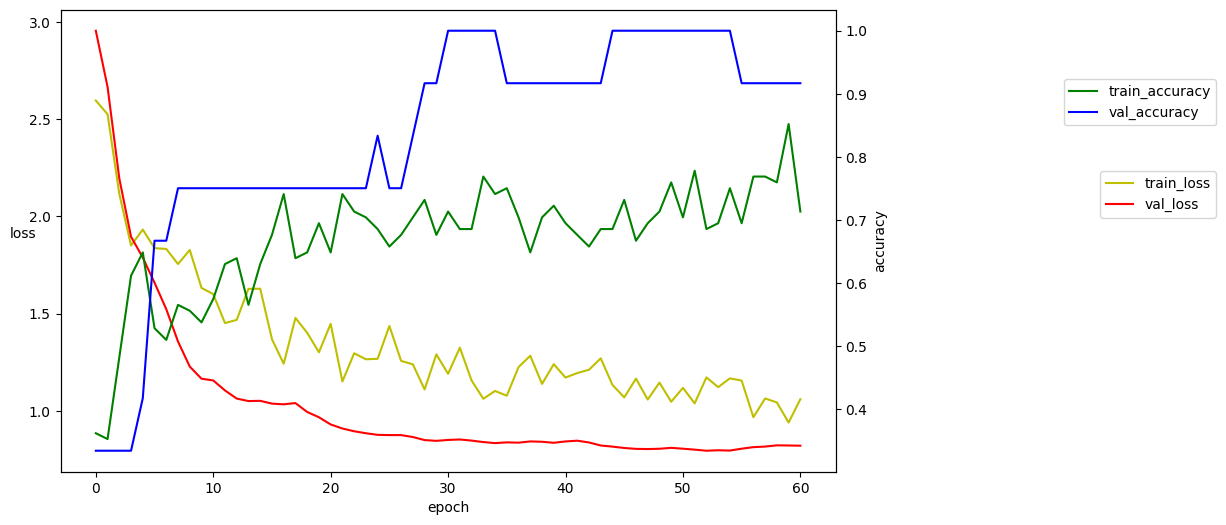

In [91]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [96]:
loss1, accuracy1 = model.evaluate(test_X, test_y)
print(f'loss : {loss:.2f}')
print(f'accuracy : {accuracy*100:.2f}%')

1/1 [==============================] - 0s 23ms/step - loss: 0.8832 - accuracy: 0.8000
loss : 0.90
accuracy : 93.33%


## 4. 모델 사용

In [94]:
model2 = load_model('model/iris_031_val_1.0000.h5')

In [97]:
loss2, accuracy2 = model2.evaluate(test_X, test_y)
print(f'loss : {loss:.2f}')
print(f'accuracy : {accuracy*100:.2f}%')

1/1 [==============================] - 0s 23ms/step - loss: 0.9038 - accuracy: 0.9333
loss : 0.90
accuracy : 93.33%


# 2. sklearn MLP
- 다층 인공신경망(Multi-Layer Perceptron) 기반의 분류 모델

In [98]:
from sklearn.neural_network import MLPClassifier # multi-layer perception

## 1. 데이터셋 생성 및 전처리
- irisData = datasets.load_iris()

## 2. 모델 구성 및 학습
- 입력 4, 출력 3, 레이어 : 4-64-128-60-30-3

In [99]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 128, 60, 30), # 은닉층 개수와 각 층의 노드 수 지정
    activation='relu', # 은닉층 활성화 함수
    solver='adam', # 가중치 최적화 알고리즘 (adam, sgd, lbfgs)
    max_iter=200, # 최대 epochs 수
    batch_size=40,
    alpha = 0.001, # L2 정규화 계수
    early_stopping=True, # 조기 종료 활성화
    n_iter_no_change=50, # early_stopping의 patience 역할
    validation_fraction=0.1, # 검증 데이터셋 비율
#     warm_start=True # 이전 학습에 이어서 학습
)

In [100]:
model.fit(train_X, train_y)

MLPClassifier(alpha=0.001, batch_size=40, early_stopping=True,
              hidden_layer_sizes=(64, 128, 60, 30), n_iter_no_change=50)

## 3. 모델 평가

In [101]:
model.score(test_X, test_y)

0.9333333333333333

## 4. 모델 사용

In [104]:
y_hat = model.predict(test_X)

In [105]:
pd.crosstab(test_y, y_hat, rownames=['real'], colnames=['pred'])

pred,0,1,2
real,,,
0,10,0,0
1,0,8,2
2,0,0,10


In [107]:
confusion_matrix(test_y, y_hat)

array([[10,  0,  0],
       [ 0,  8,  2],
       [ 0,  0, 10]], dtype=int64)

# 3. 모델 생성 함수
- 클래스 생성

In [111]:
class DNNClassifier:
    @staticmethod
    def build(input_dim=4, activation='relu', output_dim=3, optimizer='adam'):
        # 모델 구성
        model = Sequential(layers=[
                           Input(input_dim),
                           Dense(units=50, activation=activation),
                           Dense(units=30, activation=activation),
                           Dense(units=output_dim, activation='softmax')
        ], name = 'seq')
        
        # 모델 학습설정
        model. compile(loss='sparse_categorical_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])
        
        return model

In [114]:
# 1. 데이터
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

# 2. 모델 생성
model = DNNClassifier.build(input_dim=4, activation='elu', output_dim=3, optimizer='sgd')

# 3. 모델 학습
hist = model.fit(train_X, train_y,
                epochs=50,
                validation_split=0.1,
                verbose=0)

(120, 4) (120,) (30, 4) (30,)


In [116]:
# 4. 모델 평가
loss, accuracy = model.evaluate(test_X, test_y)

1/1 [==============================] - 0s 24ms/step - loss: 0.3662 - accuracy: 0.9000


# 4. 함수형 API
- 병렬 처리

In [119]:
# 기존 model
model_o = Sequential(layers=[
    Input(shape=(4,)),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax')
])

model_o.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_105 (Dense)           (None, 50)                250       
                                                                 
 dense_106 (Dense)           (None, 30)                1530      
                                                                 
 dense_107 (Dense)           (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [128]:
# 함수형 API
from tensorflow.keras import Model
input_ = Input(shape=(4,))
layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=30, activation='relu')(layer1)
output = Dense(units=3, activation='softmax')(layer2)

model = Model(inputs=input_, outputs=output)

model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_30 (InputLayer)       [(None, 4)]               0         
                                                                 
 dense_125 (Dense)           (None, 50)                250       
                                                                 
 dense_126 (Dense)           (None, 30)                1530      
                                                                 
 dense_127 (Dense)           (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [129]:
# 병렬 처리 방식

from tensorflow.keras.layers import concatenate

input_ = Input(shape=(4,))

layer1 = Dense(units=50, activation='relu')(input_)
layer2 = Dense(units=70, activation='relu')(input_)
layer3 = Dense(units=40, activation='relu')(input_)

concat_ = concatenate([layer1, layer2, layer3])

output = Dense(units=3, activation='softmax')(concat_)

model = Model(inputs=input_, outputs=output)

model.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_31 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_128 (Dense)              (None, 50)           250         ['input_31[0][0]']               
                                                                                                  
 dense_129 (Dense)              (None, 70)           350         ['input_31[0][0]']               
                                                                                                  
 dense_130 (Dense)              (None, 40)           200         ['input_31[0][0]']               
                                                                                            

# 5. Residual Block
- 신경망이 깊어질수록 오히려 학습이 잘 되지 않고 성능이 떨어지는 성능 저하 문제를 해결하기 위해 제안됨

In [130]:
from tensorflow.keras.layers import add

input_ = Input(shape=(4,))

dense1 = Dense(units=50, activation='relu')(input_)

layer1 = Dense(units=64, activation='relu')(dense1)
layer2 = Dense(units=50, activation='relu')(layer1)

dense2 = add([dense1, layer2])

output = Dense(units=3, activation='softmax')(dense2)

model = Model(inputs=input_, outputs=output)

model.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_32 (InputLayer)          [(None, 4)]          0           []                               
                                                                                                  
 dense_132 (Dense)              (None, 50)           250         ['input_32[0][0]']               
                                                                                                  
 dense_133 (Dense)              (None, 64)           3264        ['dense_132[0][0]']              
                                                                                                  
 dense_134 (Dense)              (None, 50)           3250        ['dense_133[0][0]']              
                                                                                            